In [258]:
# Instalamos las dependencias necesarias para el proyecto

!python -m pip install pandas
!python -m pip install numpy
!python -m pip install scikit.learn
!python -m pip install matplotlib
!python -m pip install seaborn
!python -m pip install plotly
!python -m pip install -U nbformat


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [259]:
# Importamos los paquetes que luego se utilizarán. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [260]:
# Transformamos el dataset a un df y lo visualizamos para tener noción sobre qué hay dentro.
data = pd.read_csv("uber_fares.csv")
data.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [261]:
print(data.shape) # (fila, columna)          
print(data.dtypes) # Tipo de dato por columna

(200000, 9)
key                    int64
date                     str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


Con esto podemos ver que hay 200.000 registros, cada uno con 9 columnas (['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']).

Además, vemos que 'date' y 'pickup_date' son str, esto lo modificaremos más adelante para un correcto uso de la información que poseen estas columnas.  

In [262]:
# Para iniciar la limpieza revisamos si hay datos duplicados. 

duplicados_totales = data.duplicated().sum()
duplicados_key = data["key"].duplicated().sum()

print("Duplicados totales:", duplicados_totales)
print("Duplicados en key:", duplicados_key)

vacios = data.isna().sum()

print(vacios)


Duplicados totales: 0
Duplicados en key: 0
key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


Revisamos los duplicados tanto de los registros completos como de las key. Este último debido a que al ser el identificador de cada viaje, demostraría una inconsistencia en el dataset en caso de duplicados. 

También podemos ver que hay un viaje que no tiene dropoff_longitude ni dropoff_latitude, como si nunca hubiese terminado. Decidimos eliminarlo, ya que lo consideramos un dato que puede generar ruido en el modelo y no es significativo a la cantidad de registros. 

In [263]:
data = data.dropna()

In [264]:
pickup_sin_tz = data["pickup_datetime"].str.split(" ", n=2).str[:2].str.join(" ")
igualdad = (data["date"] == pickup_sin_tz).all()
print(f"¿Poseen los mismos datos en todos los registros? (True/False): {igualdad}")

data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")


¿Poseen los mismos datos en todos los registros? (True/False): True


Al comprobar que 'date' y 'pickup_datetime' poseen el mismo dato, con la diferencia de que la segunda tiene también la zona horaria, podemos proceder a eliminar date, para no tener información innecesariamente duplicada. 

In [265]:
data = data.drop(columns=["date"])

data["year"] = data["pickup_datetime"].dt.year
data["month"] = data["pickup_datetime"].dt.month
data["day"] = data["pickup_datetime"].dt.day
data["hour"] = data["pickup_datetime"].dt.hour
data["weekday"] = data["pickup_datetime"].dt.weekday
data["timezone"] = data["pickup_datetime"].dt.tz

data = data.drop(columns=["pickup_datetime"])

Separamos la información de 'pickup_datetime' en año, mes, día, hora, día de la semana y zona horaria para conservar la información de forma que sea utilizable luego. Al hacer esto decidimos eliminar la columna 'pickup_datetime' para no tener redundancias innecesarias. 

In [266]:
# Visualizamos como queda el df.
data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


In [267]:
data.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.362851,-72.527631,39.935881,-72.525292,39.923890,1.684543,2011.742429,6.281841,15.704814,13.492617,3.048305
std,1.601386e+07,9.943232,11.437815,7.720558,13.117408,6.794829,1.385995,1.856395,3.438952,8.687419,6.513288,1.946946
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
1%,5.539071e+05,2.950000,-74.014402,0.000000,-74.015288,0.000000,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
5%,2.723432e+06,3.940000,-74.006838,40.701801,-74.007460,40.686410,1.000000,2009.000000,1.000000,2.000000,1.000000,0.000000
25%,1.382534e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000
50%,2.774524e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000
75%,4.155535e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000
95%,5.265729e+07,30.300000,-73.871199,40.787702,-73.874212,40.793744,5.000000,2015.000000,12.000000,29.000000,22.000000,6.000000


Viendo la salida del .describe() apreciamos valores extremos tanto de latitudes y longitudes, decidimos entonces eliminar todos los registros que tengan coordenadas no exitentes, sea:

- latitud fuera de [-90, 90]
- longitud fuera de [-180, 180]
- valores 0, 0 o una de las coordenadas en 0

In [268]:
filtro_coords_validas = (
    data["pickup_latitude"].between(-90, 90) &
    data["dropoff_latitude"].between(-90, 90) &
    data["pickup_longitude"].between(-180, 180) &
    data["dropoff_longitude"].between(-180, 180)
)

data = data[filtro_coords_validas]

filtro_no_ceros = (
    (data["pickup_latitude"] != 0) &
    (data["pickup_longitude"] != 0) &
    (data["dropoff_latitude"] != 0) &
    (data["dropoff_longitude"] != 0)
)

data = data[filtro_no_ceros]

Vemos también que 'pasenger_count' se puede ver que hay un viaje con más de doscientos pasajeros y algunos con cero, se asume que son errores de input, ya que la cantidad de pasajeros los ingresa el chofer, pero haremos un mejor estudio de los mismos y se determinará que hacer con ellos.

In [269]:
print(data["passenger_count"].value_counts().sort_index())

passenger_count
0         686
1      135635
2       28865
3        8708
4        4182
5       13740
6        4202
208         1
Name: count, dtype: int64


Que haya seis pasajeros, aunque sería incómodo a menos que se trate de un vehículo tipo SUV puede ser plausible, mientras que viajes con 0 o 200 son considerados un error en el dataset, y tambien eliminados para no comprometer la calidad del modelo.

Se consideró la posibilidad de que los viajes indicados con cero pasajeros sean envíos de paquetería, pero al no tener documentación que respalde esto decidimos no considerarlo. 

In [270]:
data = data[(data["passenger_count"] > 0) & (data["passenger_count"] <= 6)].copy()
print(data["passenger_count"].value_counts().sort_index())

passenger_count
1    135635
2     28865
3      8708
4      4182
5     13740
6      4202
Name: count, dtype: int64


Para comprender un poco mejor la distribución geográfica del dataset, se hará un mapa interactivo de los puntos de inicio y finalización de viajes. 

In [271]:
muestra = data.sample(20000, random_state=33).copy()

pickups = muestra[["pickup_latitude", "pickup_longitude"]].copy()
pickups.columns = ["lat", "lon"]
pickups["tipo"] = "Origen"

dropoffs = muestra[["dropoff_latitude", "dropoff_longitude"]].copy()
dropoffs.columns = ["lat", "lon"]
dropoffs["tipo"] = "Destino"

mapa_df = pd.concat([pickups, dropoffs], ignore_index=True)

fig = px.scatter_map(
    mapa_df,
    lat="lat",
    lon="lon",
    color="tipo",
    zoom=10,
    height=700,
    title="Puntos de inicio y finalización de los viajes",
    labels={"tipo": "Tipo de punto"},
    color_discrete_map={
        "Origen": "#00daff",
        "Destino": "#073D47"
        }
)

fig.update_layout(    
    map_style="open-street-map",
    title_x=0.5)
fig.show()

Observamos en el mapa dos situaciones que nos parece importante tener en consideración:

- Por un lado, la mayor concentración de viajes se encuentra dentro de Estados Unidos, principalmente al rededor de Nueva York. 
- Por otro, aun habiendo eliminado las coordenadas inexistentes, algunos viajes están situados sobre el océano, en el continente ártico o con una ubicación que no tiene sentido considerando que evaluamos los viajes en dólares y estos países poseen otra moneda.

Para continuar con este proyecto, nos quedaremos solo con los viajes dentro de Estados Unidos. 

In [272]:
exterior = data[
    ~(
        ((data["pickup_latitude"].between(24, 50))        &
         (data["pickup_longitude"].between(-125, -65)))   &
        ((data["dropoff_latitude"].between(24, 50))       &
         (data["dropoff_longitude"].between(-125, -65)))  
    )]
    
data = data.drop(exterior.index)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


Consideramos que un dato importante que tener es la distancia recorrida en cada viaje, calculamos una estimación de esta distancia con la ecuacion de Haversine.

In [273]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

data["distance_km"] = haversine_distance(
    data["pickup_latitude"],
    data["pickup_longitude"],
    data["dropoff_latitude"],
    data["dropoff_longitude"]
)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone,distance_km
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC,1.683323
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC,2.457590
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC,5.036377
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC,1.661683
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC,4.475450


Realizamos a continuación los histogramas de las variables 'Tarifas' y 'Distancia' para ver sus distribuciones. 

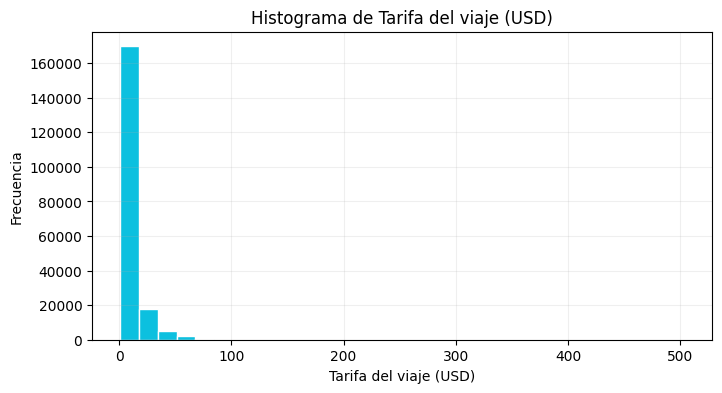

In [274]:
plt.figure(figsize=(8, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Tarifa del viaje (USD)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

In [275]:
data["fare_amount"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean         11.351422
std           9.854040
min           1.000000
1%            2.980000
5%            3.950000
25%           5.980000
50%           8.430000
75%          12.660000
95%          30.230000
99%          53.880000
max         503.130000
Name: fare_amount, dtype: float64

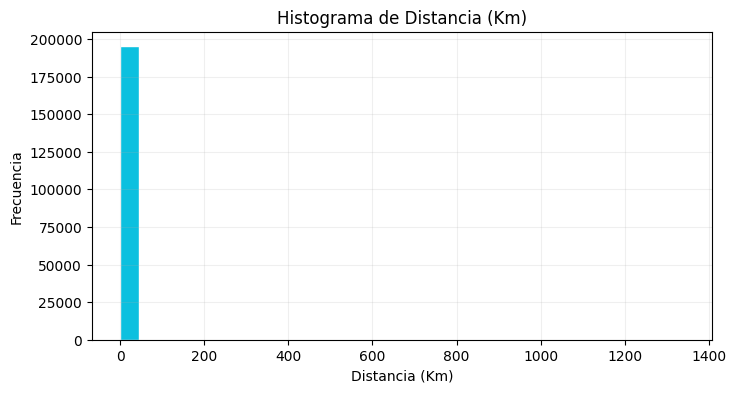

In [276]:
plt.figure(figsize=(8, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Distancia (Km)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

In [277]:
data["distance_km"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean          3.376782
std           6.391574
min           0.000000
1%            0.000000
5%            0.561803
25%           1.255903
50%           2.157198
75%           3.909870
95%          10.022799
99%          20.401307
max        1340.106401
Name: distance_km, dtype: float64

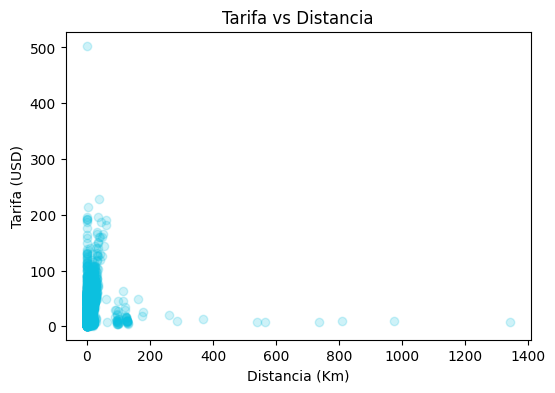

In [278]:
plt.figure(figsize=(6, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

Podemos ver tanto en los histogramas como en el scatter plot que hay outliers y que los mismos son valores atípicos, ya que hay viajes cortos con tarifas muy altas y viajes con distancias largas con tarifas muy bajas, por lo que vamos a considerar los valores por encima del 99.5% como potenciales outliers. Siendo que son variables de suma relevancia para el modelo decidimos eliminar los mismos para que no distorsionen el análisis o afecten el desempeño del modelo.

A continuación se pueden ver los gráficos luego de aplicar este corte en los datos. 

In [279]:
columnas = ["fare_amount", "distance_km"]

for col in columnas:
    limite = data[col].quantile(0.995)
    data = data[data[col] <= limite]

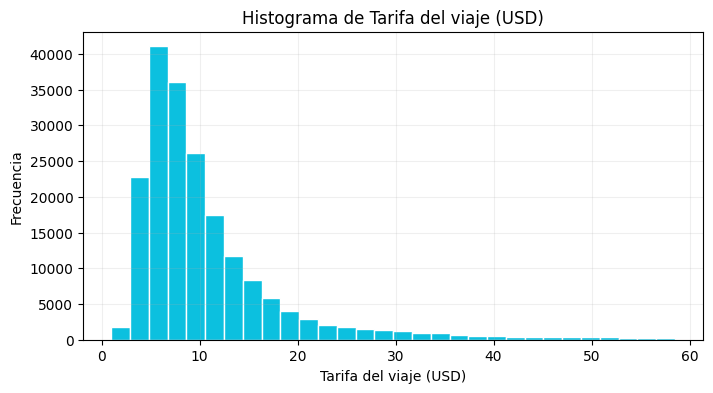

In [280]:
plt.figure(figsize=(8, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Tarifa del viaje (USD)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

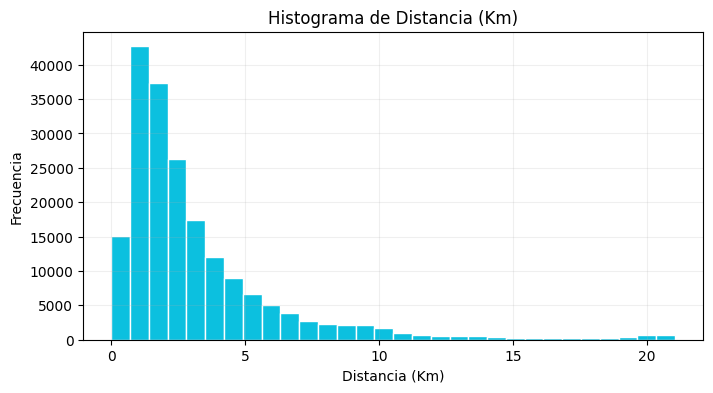

In [281]:
plt.figure(figsize=(8, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Distancia (Km)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

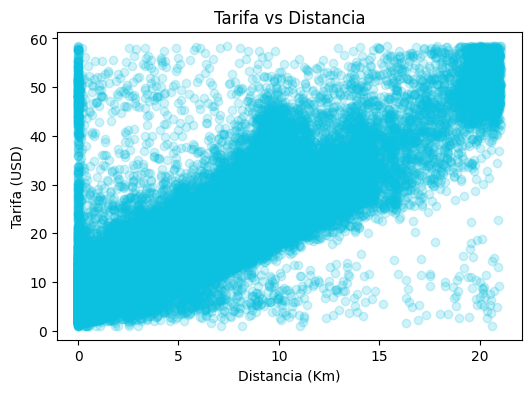

In [282]:
plt.figure(figsize=(6, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

Ahora podemos ver mucho mejor la correlación entre la distancia del viaje y la tarifa, aunque sigue habiendo algunos valores atípicos donde la distancia es mínima y las tarifas son muy altas.

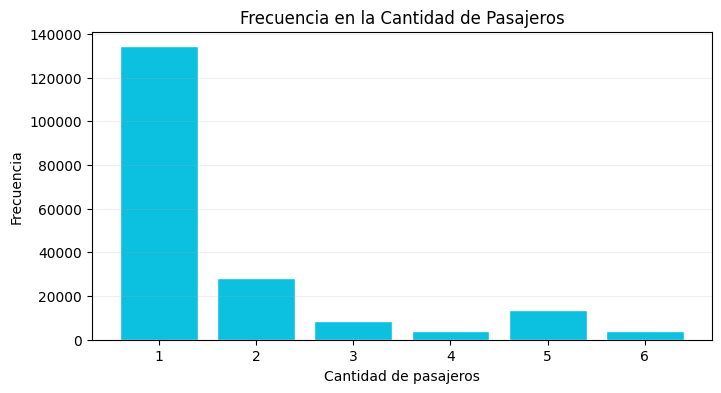

In [283]:
conteo = data["passenger_count"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Frecuencia en la Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico podemos ver que hay una fuerte tendencia a los viajes individuales.

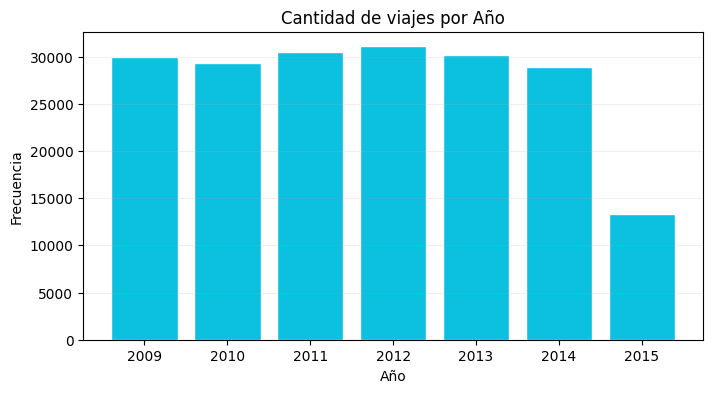

In [284]:
conteo = data["year"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por Año")
plt.xlabel("Año")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

El dataset contiene información hasta mediados del 2015, por lo que para las evaluaciones correspondientes a los meses vamos a usar una copia del dataset que solo tome hasta 2014, así evitamos distribuciones sesgadas por la falta de datos. 

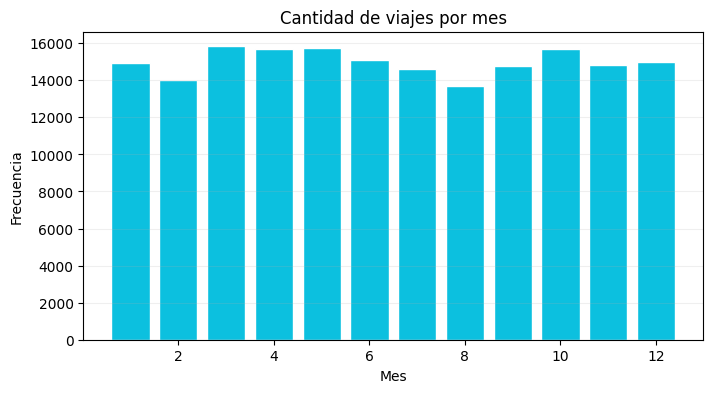

In [285]:
data_2014 = data[data["year"] < 2015].copy()

conteo = data_2014["month"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

Ahora si, se puede ver que en Marzo suele haber un aumento en la cantidad de viajes que dura por tres meses, luego un pequeño descenso que dura desde Junio hasta Agosto y en Septiembre y octubre vuelven a incrementar los viajes hasta noviembre. Se puede apreciar que en EEUU (dónde la mayoría de los viajes de este dataset son) es verano entre Junio y Septiembre, así que se puede teorizar que la baja de viajes entre esos meses podría ser por la gente que elige vacacionar o estudiantes que no tienen que ir a la universidad/escuela.

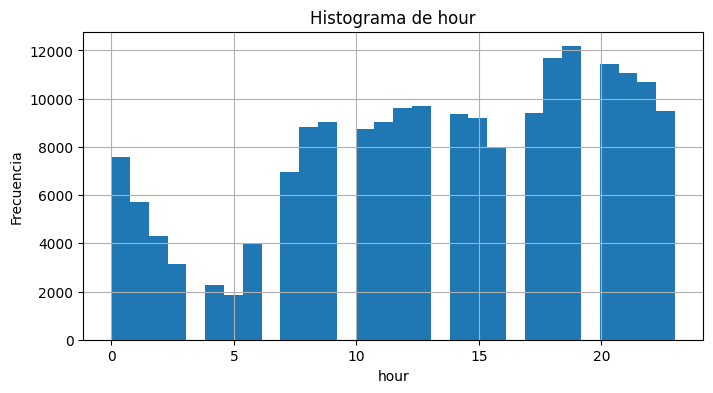

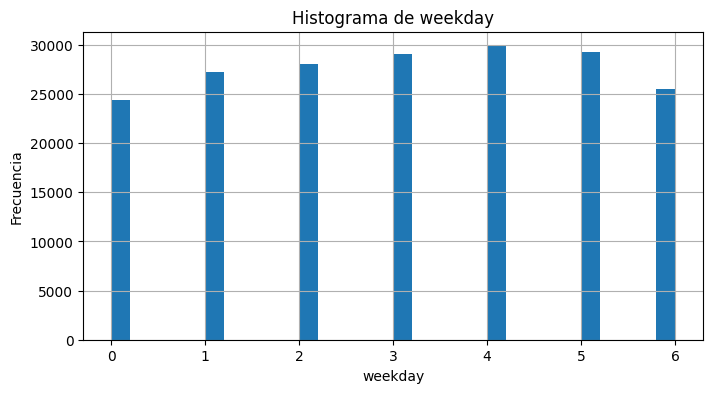

In [286]:
columnas = [
    "hour",
    "weekday"
]

for col in columnas:
    plt.figure(figsize=(8, 4))
    data[col].hist(bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Acá se puede notar que la mayoría de viajes se dan entre el atardecer y la noche, antes de la madrugada, y que los últimos días de la semana son en los que más se solicitan viajes.

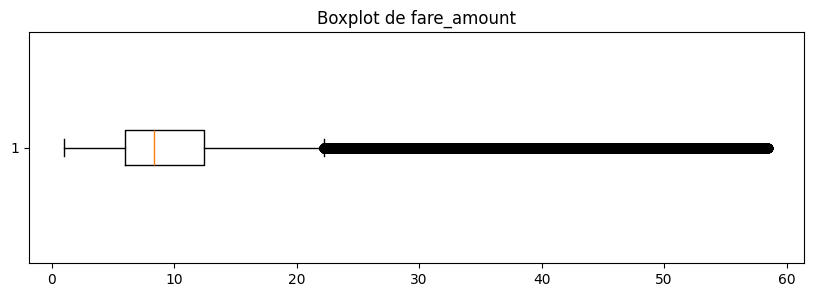

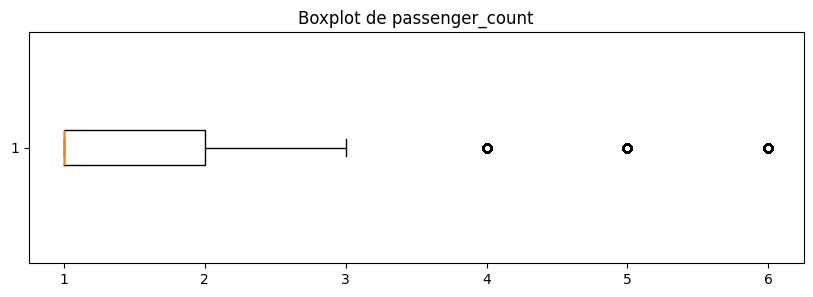

In [287]:
#se genera un boxplot de cada columna relevante
for col in ["fare_amount", "passenger_count"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

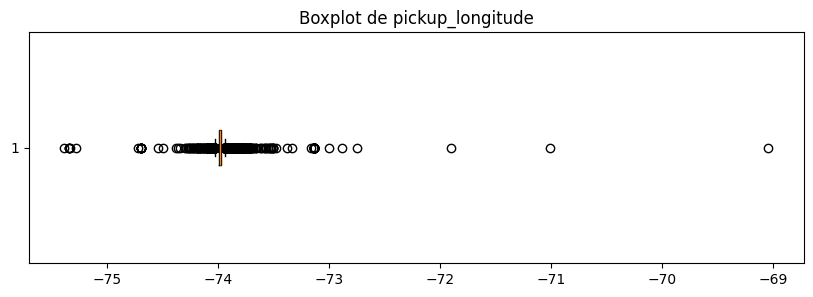

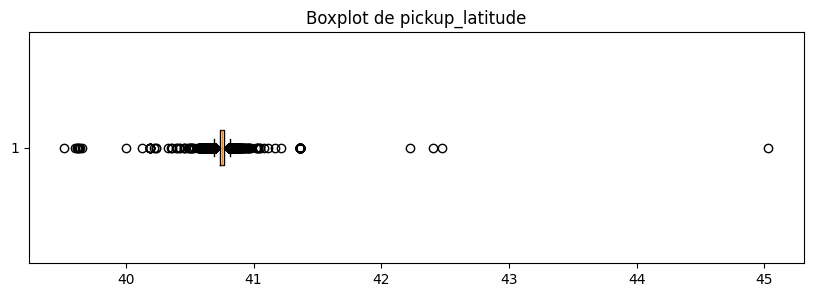

In [288]:
#se genera un boxplot de cada columna relevante
for col in ["pickup_longitude", "pickup_latitude"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

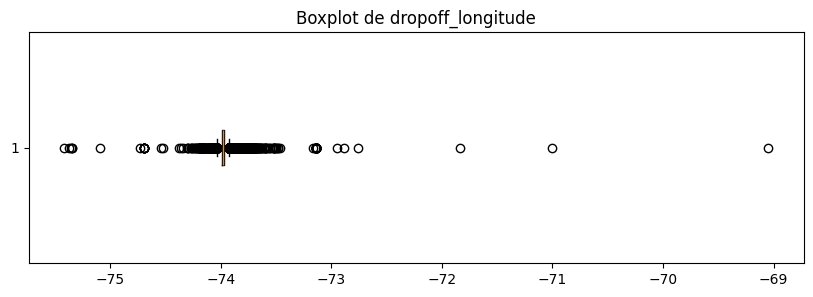

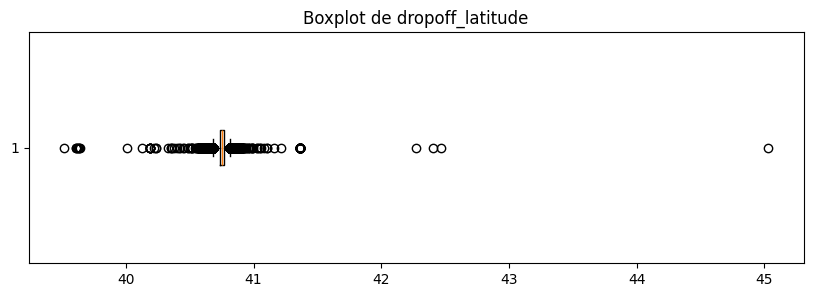

In [289]:
#se genera un boxplot de cada columna relevante
for col in ["dropoff_longitude", "dropoff_latitude"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

si bien existen algunos outlyers extremos, no son datos que se sientan tan extraños al dataset cómo antes.

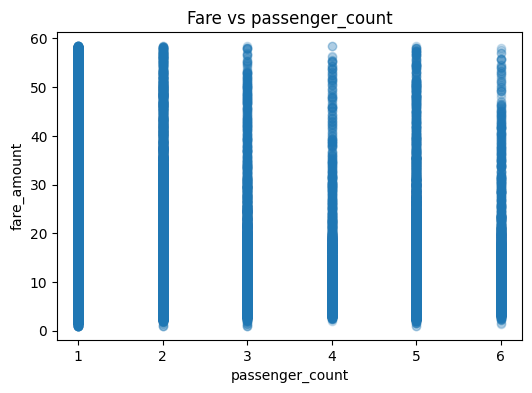

In [290]:
plt.figure(figsize=(6, 4))
plt.scatter(data["passenger_count"], data["fare_amount"], alpha=0.2)
plt.title("Fare vs passenger_count")
plt.xlabel("passenger_count")
plt.ylabel("fare_amount")
plt.show()

se puede ver una preferencia de los pasajeros únicos a hacer viajes más largos.

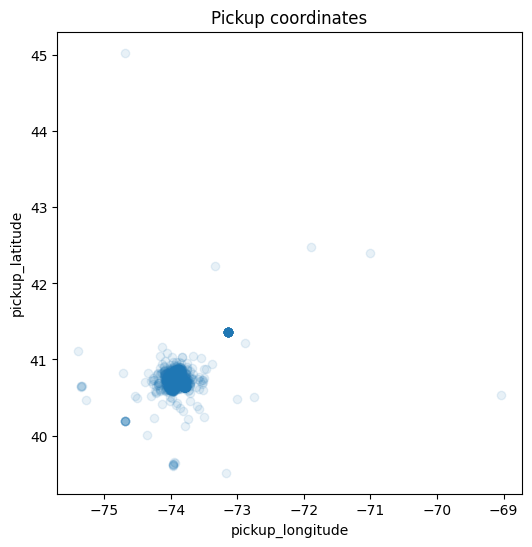

In [291]:
plt.figure(figsize=(6, 6))
plt.scatter(data["pickup_longitude"], data["pickup_latitude"], alpha=0.1)
plt.title("Pickup coordinates")
plt.xlabel("pickup_longitude")
plt.ylabel("pickup_latitude")
plt.show()

se puede ver una fuerte concentración de viajes por las mismas zonas con algunas excepciones coherentes

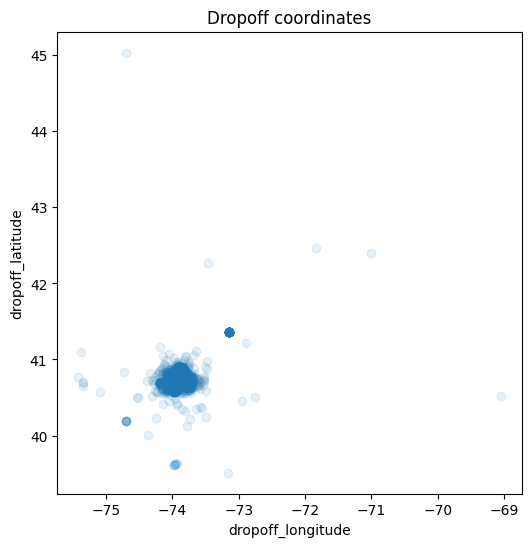

In [292]:
plt.figure(figsize=(6, 6))
plt.scatter(data["dropoff_longitude"], data["dropoff_latitude"], alpha=0.1)
plt.title("Dropoff coordinates")
plt.xlabel("dropoff_longitude")
plt.ylabel("dropoff_latitude")
plt.show()

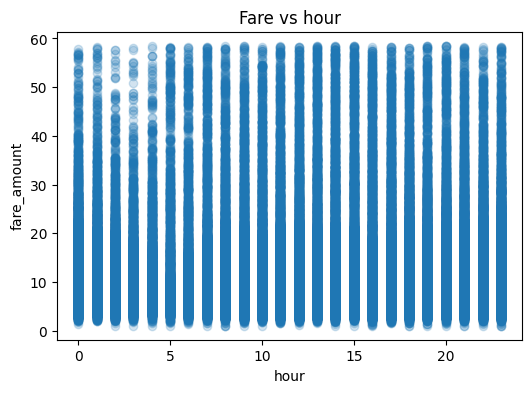

In [293]:
plt.figure(figsize=(6, 4))
plt.scatter(data["hour"], data["fare_amount"], alpha=0.2)
plt.title("Fare vs hour")
plt.xlabel("hour")
plt.ylabel("fare_amount")
plt.show()

no se encuentra algún tipo de patrón o simetría entre el costo del viaje y la hora a la que fué tomado el mismo

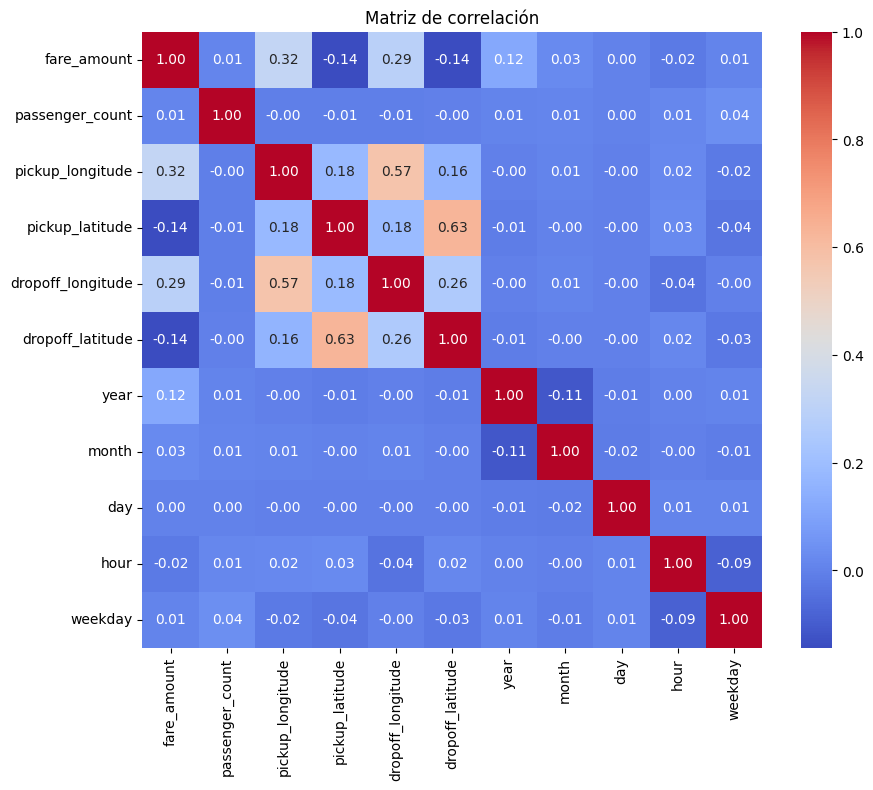

In [294]:
corr_cols = [
    "fare_amount",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "year",
    "month",
    "day",
    "hour",
    "weekday"
]

corr = data[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# Codificación de variables  
se opta por codificar mediante one-hot las variables de mes, hoya y día de semana para que el modelo no interprete que hay alguna relación ordinal entre ellas.

In [295]:
#se dropean las columna que no son predictores
X = data.drop(columns=["fare_amount", "key", "pickup_datetime"])
y = data["fare_amount"]

#se codifican las columnas necesarias
X = pd.get_dummies(X, columns=["month", "weekday", "hour"], drop_first=True)

KeyError: "['pickup_datetime'] not found in axis"

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66)

In [ ]:
#se escalan los datos
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(156138, 47)
(39035, 47)
